In [1]:
# Assumes the following files exist:
# 
# - trial.npz (full 3D trial)
# - trial.p100.npz (2D trial p100)
# - metadata.csv (i.e., a currently selected metadata file)
# - metadata.XXYY.npz (i.e. for each set of extraction bb-merge parameters)
# - 

In [2]:
import sys
sys.path.append('..')

In [3]:
import utils
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
%matplotlib widget

In [4]:
metadata_filepaths = list(utils.cc_root.glob('**/metadata.csv'))

In [5]:
trial_id = 0

In [6]:
metadata_filepath = metadata_filepaths[trial_id]

trial_folder = metadata_filepath.parent

trial_p100 = np.load(trial_folder / 'trial.p100.npz')['arr_0']

In [7]:
print(f'Processing {trial_folder}')

Processing /home/shared/cc/386/2023-11-01/in/38


In [8]:
def load_metadata():
  return pd.read_csv(metadata_filepath)

metadata = load_metadata()

def save_metadata():
  global metadata
  metadata.to_csv(metadata_filepath, index=False)

# Select best footstep extraction parameters

In [9]:
def compute_bb_area(row):
  return (row.XMax-row.XMin) * (row.YMax-row.YMin)

# variance
def compute_bb_variance(df):
  if len(df) == 0:
    return 0
  
  areas = [compute_bb_area(r) for _, r in df.iterrows()]
  return np.var(areas)


records = []

for config in utils.metadata_configs:
  metadata_filepath = trial_folder / f'metadata.{config}.csv'

  try:
    metadata_df = pd.read_csv(metadata_filepath)
  except FileNotFoundError:
    continue

  # variance loss criteria expects a "good" extraction to result in uniform bb area. However, it is completely valid to draw small BBs around
  # incomplete footsteps at the edge of the tile grid.
  #
  # Therefore, don't consider these footsteps in the loss calculation
  #
  # TODO: This area calculation should really be on the aligned version of the footstep.
  metadata_df['area'] = metadata_df.apply(compute_bb_area, axis=1)
  small_area_threshold = np.quantile(metadata_df.area, 0.25)
  metadata_df['is_small'] = metadata_df.apply(lambda r: r.area < small_area_threshold, axis=1)


  edge_threshold_px = 5
  def is_incomplete_footstep(row):
    on_grid_edge = row.XMin < (0+edge_threshold_px) or row.XMax > (480-edge_threshold_px) or row.YMin < (0+edge_threshold_px) or row.YMax > (720-edge_threshold_px)
    return row.is_small and on_grid_edge

  metadata_df['is_incomplete'] = metadata_df.apply(is_incomplete_footstep, axis=1)

  record = {}
  record['config'] = config
  record['n_steps'] = len(metadata_df)
  record['variance'] = compute_bb_variance(metadata_df.query('is_incomplete == False'))
  records.append(record)

extraction_table = pd.DataFrame(records)

In [10]:
# normalize to range [0, 1]
def normalize_range(vals):
  if len(vals) == 0:
    return []
  
  vals = np.array(vals)

  min_val = np.min(vals)
  max_val = np.max(vals)


  if min_val == max_val:
    normalized_score = np.sqrt(0.5)
    return np.array([normalized_score] * len(vals))

  normalized_scores = np.sqrt((vals-min_val) / (max_val-min_val))
  return normalized_scores


extraction_table['n_steps_norm'] = normalize_range(extraction_table['n_steps'])
extraction_table['variance_norm'] = normalize_range(extraction_table['variance'])

extraction_table['loss'] = (extraction_table['n_steps_norm'] + extraction_table['variance_norm']) / 2

winner_idx = np.argmin(extraction_table['loss'])
extraction_table['winner'] = ''
extraction_table.loc[winner_idx, 'winner'] = '*'

extraction_table

,config,n_steps,variance,n_steps_norm,variance_norm,loss,winner
0,2020,16,60855.943878,1.000000,0.232292,0.616146,
1,2025,16,60855.943878,1.000000,0.232292,0.616146,
2,2030,16,60855.943878,1.000000,0.232292,0.616146,
3,2035,14,324611.454082,0.894427,0.688987,0.791707,
4,2040,14,324611.454082,0.894427,0.688987,0.791707,
5,2520,9,27029.632653,0.547723,0.000000,0.273861,*
6,2525,9,27029.632653,0.547723,0.000000,0.273861,
7,2530,9,27029.632653,0.547723,0.000000,0.273861,
8,2535,7,405174.857143,0.316228,0.776671,0.546449,
9,2540,7,405174.857143,0.316228,0.776671,0.546449,


In [11]:
best_config = extraction_table.loc[winner_idx, 'config']
best_metadata_filepath = trial_folder / f'metadata.{best_config}.csv'

# save the best configuration in `metadata.csv` for future use
metadata = pd.read_csv(best_metadata_filepath)
save_metadata()

# Populate any missing metadata columns

In [12]:
if 'Direction' not in metadata.columns:
  participant_id, date, direction, swipe_n = utils.parse_identifying_components_from_path(metadata_filepath)
  metadata['ParticipantID'] = participant_id 
  metadata['Date'] = date
  metadata['Direction'] = direction
  metadata['SwipeN'] = swipe_n
  save_metadata()

if 'x' not in metadata.columns:
  metadata['x'] = (metadata.XMin + metadata.XMax) / 2
  metadata['y'] = (metadata.YMin + metadata.YMax) / 2
  metadata['t'] = (metadata.StartFrame + metadata.EndFrame) / 2

# Identify Invalid Footsteps

In [13]:
short_dimension_min, short_dimension_max = 15, 80
long_dimension_min, long_dimension_max = 40, 100
def is_within_expected_bb_size(row):
  x_length = row.XMax - row.XMin
  y_length = row.YMax - row.YMin

  short_length = min(x_length, y_length)
  long_length = max(x_length, y_length)

  return (short_dimension_min < short_length < short_dimension_max) and (long_dimension_min < long_length < long_dimension_max)


t_min, t_max = 50, 400
def is_within_expect_duration(row):
  duration = row.EndFrame - row.StartFrame 
  return t_min < duration < t_max


sanity_checks = [is_within_expected_bb_size, is_within_expect_duration]
for i, row in metadata.iterrows():
  for check in sanity_checks:
    if not check(row):
      metadata.loc[i, 'valid'] = False
      continue

metadata.valid = metadata.valid.apply(bool)
metadata.valid

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7    False
8    False
Name: valid, dtype: bool

# Footstep Extraction

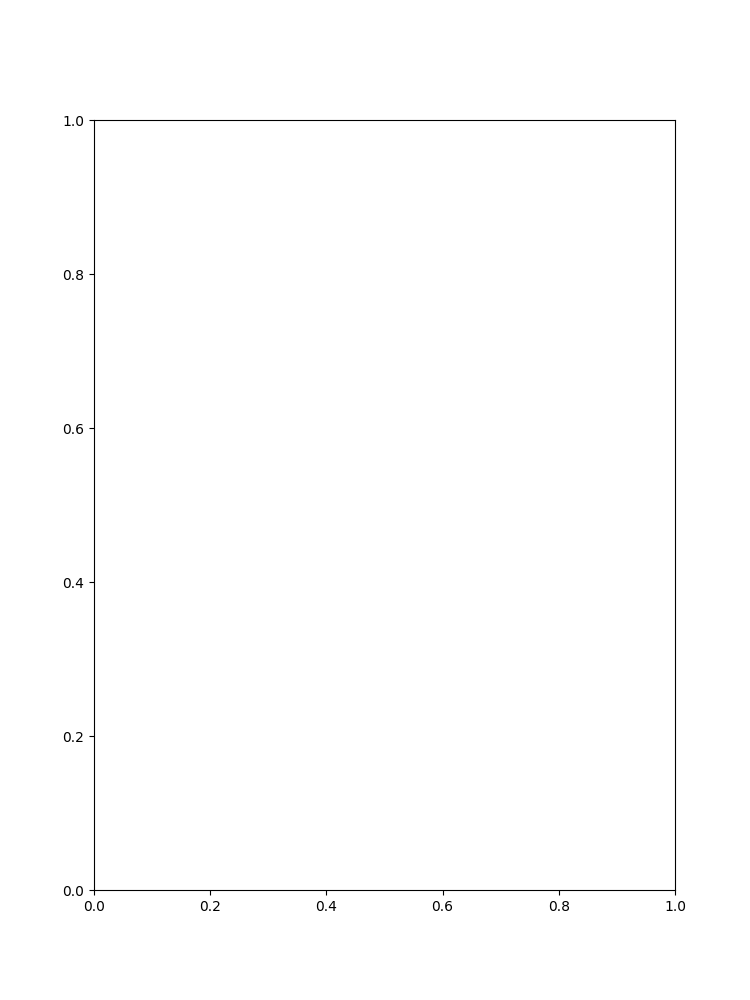

In [14]:
extraction_fig, extraction_ax = plt.subplots(figsize=(7.5, 10))

In [15]:
def draw_extraction_plot():
  
  # Clear existing content
  extraction_ax.clear()
  extraction_ax.set_xlim((0,480))
  extraction_ax.set_ylim((720,0))
  
  # Plot the P100
  extraction_ax.imshow(trial_p100) #, norm='log')

  # Plot tile grids
  for r_start, _ in utils.tile_boundaries[:6]:
    extraction_ax.hlines(y=r_start, xmin=0, xmax=480, colors='grey', linestyles='dashed', linewidths=0.5)

  for c_start, _ in utils.tile_boundaries[:4]:
    extraction_ax.vlines(x=c_start, ymin=0, ymax=720, colors='grey', linestyles='dashed', linewidths=0.5)

  # Plot current bounding boxes
  for _, row in metadata.iterrows():
    color = 'green' if row.valid else 'red'
    rect = plt.Rectangle((row.XMin, row.YMin), row.XMax-row.XMin, row.YMax-row.YMin, fill=False, color=color, linewidth=1.5)
    extraction_ax.add_patch(rect)
  
  # Plot trial bounding box
  r = metadata.loc[0]
  rect = plt.Rectangle((r.Trial_XMin, r.Trial_YMin), r.Trial_XMax - r.Trial_XMin, r.Trial_YMax - r.Trial_YMin, fill=False, color='grey', alpha=0.5, linewidth=2, linestyle='--')
  extraction_ax.add_patch(rect)

  # Plot footstep ids
  for footstep_id, row in metadata.iterrows():
    centroid = ((row.XMax+row.XMin)/2, (row.YMax+row.YMin)/2)
    extraction_ax.annotate(f'{footstep_id} ({row.t/100:.1f})', centroid, color='white')
  
  # Plot gate
  gate_id = metadata.loc[0, 'Gate']

  # 1 and 3 are in-gates
  # 2 and 4 are out-gates
  # ASSUMING that 1 and 2 are the RIGHTMOST gate

  if gate_id in [1, 2]:
    gate_xmin = 160
  else:
    gate_xmin = 0

  rect = plt.Rectangle((gate_xmin, 5), 120, 5, fill=True, color='grey', alpha=0.7, linewidth=0)
  extraction_ax.add_patch(rect)

  # Add title
  r = metadata.loc[0]
  # title_str = f'{r.Participant} {r.Date} {r.Direction} {r.SwipeN}'
  title_str = metadata_filepath
  extraction_ax.set_title(title_str)

draw_extraction_plot()

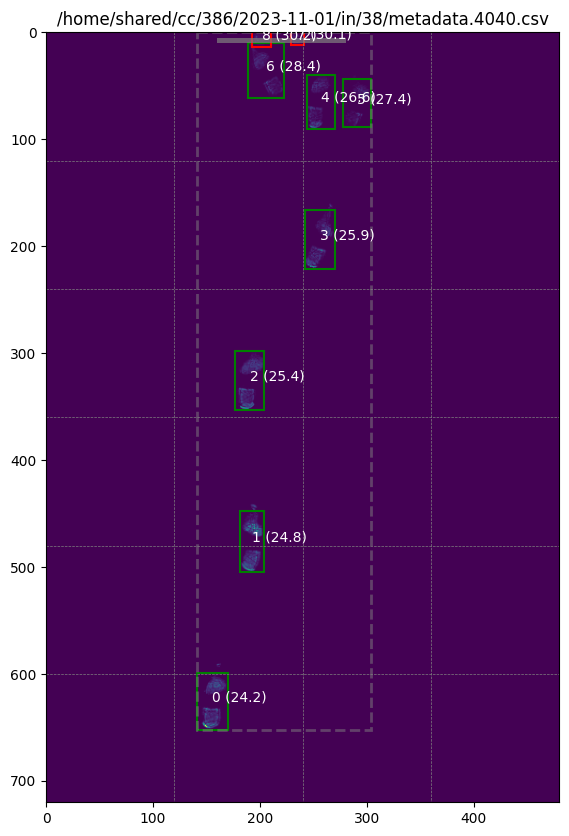

In [16]:
# This line is a workaround to display the figure as a static image in this notebook when generated programatically by papermill
# It isn't necessary when working interactively with ipywidgets (the plot will be rended in the preceding cell)
extraction_fig

In [17]:
extraction_fig.savefig(fname = trial_folder / 'extraction.png')

In [18]:
# populate a dropdown that allows users to try different configurations
merge_vals = '20 25 30 35 40'.split()

merge_configs = []
for x in merge_vals:
  for y in merge_vals:
    merge_configs += [f'{x}{y}']


merge_config_dropdown = widgets.Dropdown(
  options=merge_configs,
  value=str(int(metadata.loc[0, 'ExtractionParameters'])),
  description='Merge Params:',
)

def regenerate_after_config_selection():
  global metadata_filepath
  global metadata

  selected_param = merge_config_dropdown.value

  metadata_filename = trial_folder / f'metadata.{selected_param}.csv'
  
  metadata = pd.read_csv(metadata_filename)
  draw_extraction_plot()


display(merge_config_dropdown)

Dropdown(description='Merge Params:', index=5, options=('2020', '2025', '2030', '2035', '2040', '2520', '2525'…

# Exclude Trails Based on Real-World Sanity Checks

In [19]:
# based on the absence of footsteps near the gate
def get_footsteps_contained_in_box(metadata, xmin, xmax, ymin, ymax):
  footstep_ids = []
  for _, r in metadata.iterrows():
    if xmin <= r.x <= xmax and ymin <= r.y <= ymax:
      footstep_ids.append(r.FootstepID)
  
  return footstep_ids

# if no footsteps exist in the top-most region of the mat, this is clearly a problematic recording that should be discarded
footstep_ids = get_footsteps_contained_in_box(metadata, xmin=0, xmax=480, ymin=0, ymax=150)
if len(footstep_ids) == 0:
  print('Aborting: This trial does not contain any footsteps near the gate')
  raise Exception


# based on fewer than a specified number of footsteps
footstep_count_lower_threshold = 3
if len(metadata) < footstep_count_lower_threshold:
  print(f'Aborting: Fewer that {footstep_count_lower_threshold} found in trial')
  raise Exception 

# based on a specified min duration between first and last footstep
start_frame = metadata.t.min()
end_frame = metadata.t.max()

trial_duration_lower_threshold = 100 # i.e., one second
if end_frame-start_frame < trial_duration_lower_threshold:
  print(f'Aborting: Trial contains less than {trial_duration_lower_threshold} frames worth of footstep data.')
  raise Exception

# Anchor Identification

In [20]:
max_distance = np.sqrt(220**2 + 660**2)

# The anchor footstep is used to trace the participant's path of travel.
# It is the closest (spatio-temporal) footstep to the swipe event for this trial
def identify_anchor_footstep(metadata):
  if metadata.Direction[0] == 'out':
    # the anchor footstep should occur at a short delay following the swipe
    delay = 25
    temporal_loss = np.array([abs(delay-t)/(3000-delay) for t in metadata.t])
  else:
    # we want the footstep that falls closest to 30-seconds
    temporal_loss = np.array([abs(3000-t) / 3000 for t in metadata.t])
    
  y_target = 10
  gate = metadata.Gate[0]
  x_target = 60 if gate in [3,4] else 220

  delta_y = np.abs(metadata.y - y_target)
  delta_x = np.abs(metadata.x - x_target)

  distance_from_target = np.sqrt(delta_x**2 + delta_y**2)
  distance_loss = distance_from_target / max_distance
  
  loss = (np.sqrt(temporal_loss) + np.sqrt(distance_loss)) / 2

  '''
  # Invalid footsteps cannot be the anchor.
  loss[metadata.valid == False] = 1.0
  '''

  min_idx = loss.argmin()

  metadata.loc[min_idx, 'path_order'] = 0

  if True:
    print('Anchor Identification:')
    for i, (f, l) in enumerate(zip(metadata.FootstepID, loss)):
      if i == min_idx:
        print(f'{f}: {l:.02f} *') 
      else:
        print(f'{f}: {l:.02f}')


metadata['path_order'] = -1
identify_anchor_footstep(metadata)

Anchor Identification:
0: 0.69
1: 0.62
2: 0.53
3: 0.44
4: 0.32
5: 0.33
6: 0.22
7: 0.10 *
8: 0.13


# Path Tracing

## Compute a heading vector for each footstep

In [21]:
from sklearn.decomposition import PCA

# Note that this actually ends up being 180-degrees out for all in-bound footsteps. However, this
# is the direction to the next step that we want to find in our path anyway.
def get_heading(row):
  bb = row['XMin XMax YMin YMax'.split()]
  p100 = trial_p100[bb.YMin:bb.YMax, bb.XMin:bb.XMax]
  
  c, r = np.where(p100 > 0)
  X = np.array([c,r]).T

  pca = PCA(n_components=2)
  reducer = pca.fit(X)
  angle_needed_to_upright = np.arctan2(pca.components_[0,1], pca.components_[0,0])

  heading_angle = angle_needed_to_upright + 0.5*np.pi

  tau = 2*np.pi
  if heading_angle > tau:
    heading_angle -= tau
  
  if heading_angle < 0:
    heading_angle += tau
  
  return heading_angle

metadata['heading_angle'] = metadata.apply(get_heading, axis=1)

## Trace path beginning from anchor

In [22]:
def get_angle_between(f1, f2):
  dx = f2.x - f1.x
  dy = f2.y - f1.y
  a = np.arctan2(-dy, dx)

  if a < 0:
    a += 2*np.pi

  return a

## assumes that path order is populated for all steps currently on the path
def find_next_footstep(metadata, current_footstep_id):
  current_footstep = metadata.loc[current_footstep_id]

  remaining_candidates = metadata.query('path_order < 0')

  if current_footstep.Direction == 'in':
    # We are tracing backward through time. Next step must occur in some sane window of time before the current one
    remaining_candidates = remaining_candidates.query('@current_footstep.t-150 < t < @current_footstep.t-10')
  else:
    # We are tracing forward through time. Next step must occur in some sane window of time after the current one
    remaining_candidates = remaining_candidates.query('@current_footstep.t+150 > t > @current_footstep.t+10')


  ## TODO: Something funny is going on here...
  distance_to_candidates = np.sqrt((remaining_candidates.x-current_footstep.x)**2 + (remaining_candidates.y-current_footstep.y)**2)

  print('Distances')
  print(distance_to_candidates)

  remaining_candidates = remaining_candidates[distance_to_candidates < 250]

  if len(remaining_candidates) == 0:
    return {}
  

  def normalize_range(a):
    # This allows is to still pass the stop criteria threshold and be added to the path
    if len(a) == 1:
      return np.array([0.1])
    
    return (a-np.min(a)) / (np.max(a)-np.min(a))
  
  dys = np.abs(remaining_candidates.y.to_numpy() - current_footstep.y)
  dxs = np.abs(remaining_candidates.x.to_numpy() - current_footstep.x)

  d_loss = np.sqrt(dxs**2 + dys**2)
  d_loss = normalize_range(d_loss)

  t_loss = np.abs(remaining_candidates.t.to_numpy() - current_footstep.t)
  t_loss = normalize_range(t_loss)

  '''
  # in addition to favoring more temporally proximate candidates,
  # candidates exceedinging a certain absoulte duration threshold should be heavily penalized
  delta_t = np.abs(remaining_candidates.t.to_numpy() - current_footstep.t)
  t_absolute_loss = (delta_t / 1000).clip(max=1)
  '''
  

  angle_btwn = np.array([get_angle_between(current_footstep, candidate) for _, candidate in remaining_candidates.iterrows()])

  desired_angle = (current_footstep.heading_angle+np.pi) % (2*np.pi)
  
  a_loss = np.abs(angle_btwn - desired_angle)
  a_loss = normalize_range(a_loss)

  loss = (np.sqrt(d_loss) + np.sqrt(t_loss) + np.sqrt(a_loss)) / 3

  loss_dict = {f: l for f, l in zip(remaining_candidates.FootstepID, loss)}
  return loss_dict

In [23]:
def trace_path(metadata):

  # Start from the anchor footstep
  current_footstep_id = metadata.query('path_order == 0').FootstepID.iloc[0]

  next_path_order = 1
  while next_path_order < len(metadata):  
    loss_dict = find_next_footstep(metadata, current_footstep_id)

    min_loss = 1
    min_footstep_id = -1
    for f, l in loss_dict.items():
      if l <= min_loss:
        min_loss = l
        min_footstep_id = f

    next_footstep_id, next_loss = min_footstep_id, min_loss

    print(f'Path Node: {next_path_order} (#{current_footstep_id}):')
    for k, v in loss_dict.items():
      if k == next_footstep_id:
        print(f'\t{k}: {v:.2f} *')
      else:
        print(f'\t{k}: {v:.2f}')


    # Path termination. Evidence suggesting that we have reached the end of the path:
    # a) current footstep is near edge of grid
    # b) current headings points off of grid.
    # c) all next-step candidates are improbable
    current_footstep = metadata.loc[current_footstep_id]

    x = current_footstep.x
    y = current_footstep.y

    px_from_x_edge = min(x, 480-x)
    x_loss = px_from_x_edge / 480

    px_from_y_edge = min(y, 720-y)
    y_loss = px_from_y_edge / 720
    

    edge_loss = min(x_loss, y_loss)

    trajectory_angle = (current_footstep.heading_angle+np.pi) % (2*np.pi)
    angle_to_grid_center = np.arctan2(-(360-y),(240-x))
    angle_difference = (trajectory_angle - angle_to_grid_center) % (2*np.pi)
    angle_deviation = min(angle_difference, 2*np.pi - angle_difference)
    a_loss = 1 - (angle_deviation / np.pi)

    improbable_loss = 1 - next_loss


    print([f'{l:.2f}' for l in [x_loss, y_loss, a_loss, improbable_loss]])

    stop_loss = (np.sqrt(edge_loss) + np.sqrt(a_loss) + np.sqrt(improbable_loss)) / 3
    print(f'\tstop loss: {stop_loss:.2f}')

    if (len(loss_dict) == 0) or stop_loss < 0.2:
      break
    
    metadata.loc[next_footstep_id, 'path_order'] = next_path_order
    
    current_footstep_id = next_footstep_id
    next_path_order += 1


# reset all path nodes EXCEPT for the
def reset_path_order(row):
  if row.path_order == 0:
    return 0
  else:
    return -1

metadata['path_order'] = metadata.apply(reset_path_order, axis=1)

trace_path(metadata)

Distances
Series([], dtype: float64)
Path Node: 1 (#7):
['0.49', '0.01', '0.83', '0.00']
	stop loss: 0.33


In [24]:
metadata

,Unnamed: 0,FootstepID,StartFrame,EndFrame,YMin,YMax,XMin,XMax,Timestamp,Gate,...,x,y,t,valid,ParticipantID,Date,Direction,SwipeN,path_order,heading_angle
0,0,0,2389,2457,599,652,141,170,2023-10-31 09:28:31,1,...,155.5,625.5,2423.0,True,386,2023-11-01,in,38,-1,1.414661
1,1,1,2445,2515,448,505,181,204,2023-10-31 09:28:31,1,...,192.5,476.5,2480.0,True,386,2023-11-01,in,38,-1,1.529053
2,2,2,2502,2573,298,353,177,204,2023-10-31 09:28:31,1,...,190.5,325.5,2537.5,True,386,2023-11-01,in,38,-1,1.374457
3,3,3,2557,2633,166,221,242,270,2023-10-31 09:28:31,1,...,256.0,193.5,2595.0,True,386,2023-11-01,in,38,-1,1.265754
4,4,4,2617,2708,40,90,244,270,2023-10-31 09:28:31,1,...,257.0,65.0,2662.5,True,386,2023-11-01,in,38,-1,1.383193
5,5,5,2681,2795,44,89,278,304,2023-10-31 09:28:31,1,...,291.0,66.5,2738.0,True,386,2023-11-01,in,38,-1,1.318893
6,6,6,2759,2917,10,61,189,222,2023-10-31 09:28:31,1,...,205.5,35.5,2838.0,True,386,2023-11-01,in,38,-1,1.982706
7,7,7,2865,3149,0,12,229,241,2023-10-31 09:28:31,1,...,235.0,6.0,3007.0,False,386,2023-11-01,in,38,0,2.111629
8,8,8,2947,3101,0,14,193,210,2023-10-31 09:28:31,1,...,201.5,7.0,3024.0,False,386,2023-11-01,in,38,-1,2.972960


In [25]:
metadata['FootstepID path_order valid'.split()]

,FootstepID,path_order,valid
0,0,-1,True
1,1,-1,True
2,2,-1,True
3,3,-1,True
4,4,-1,True
5,5,-1,True
6,6,-1,True
7,7,0,False
8,8,-1,False


In [26]:
metadata['is_anchor'] = metadata.path_order == 0
metadata['is_on_path'] = metadata.path_order >= 0

anchor_id = metadata.query('is_anchor == True').FootstepID.iloc[0]

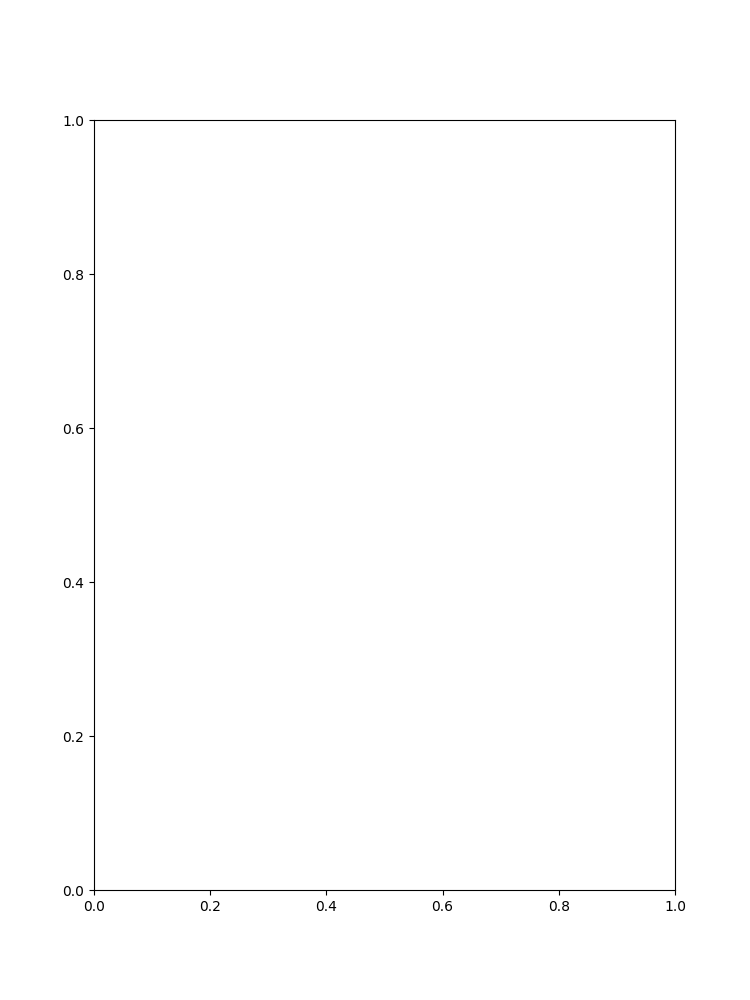

In [27]:
path_fig, path_ax = plt.subplots(figsize=(7.5,10))

In [28]:
def draw_path_plot():
  
  valid_footsteps = metadata.query('valid == True')

  # Clear existing content
  path_ax.clear()
  path_ax.set_xlim((0,480))
  path_ax.set_ylim((720,0))
  
  # Plot the P100
  path_ax.imshow(trial_p100)

  # Plot tile grids
  for r_start, _ in utils.tile_boundaries[:6]:
    path_ax.hlines(y=r_start, xmin=0, xmax=480, colors='grey', linestyles='dashed', linewidths=0.5)

  for c_start, _ in utils.tile_boundaries[:4]:
    path_ax.vlines(x=c_start, ymin=0, ymax=720, colors='grey', linestyles='dashed', linewidths=0.5)

  # Plot current bounding boxes
  for _, row in valid_footsteps.iterrows():
    rect = plt.Rectangle((row.XMin, row.YMin), row.XMax-row.XMin, row.YMax-row.YMin, fill=False, color='green', linewidth=1.5)
    path_ax.add_patch(rect)
  
  # Plot trial bounding box
  if len(valid_footsteps):
    r = valid_footsteps.iloc[0]
    rect = plt.Rectangle((r.Trial_XMin, r.Trial_YMin), r.Trial_XMax - r.Trial_XMin, r.Trial_YMax - r.Trial_YMin, fill=False, color='grey', alpha=0.5, linewidth=2, linestyle='--')
    path_ax.add_patch(rect)

  # Plot a heading arrow
  for footstep_id, row in valid_footsteps.iterrows():
    x = row.x
    y = row.y
    a = row.heading_angle

    dx = 20 * np.cos(a)
    dy = 20 * np.sin(a)

    # note that dy is NEGATIVE because of inverted image y-coordinate system
    path_ax.arrow(x, y, dx, -dy, color='white', width=1)

  # Plot footstep ids
  for footstep_id, row in valid_footsteps.iterrows():
    centroid = ((row.XMax+row.XMin)/2, (row.YMax+row.YMin)/2)
    path_ax.annotate(f'{footstep_id} ({row.t})', centroid, color='white')
  
  # Plot steps in path
  for _, row in valid_footsteps.iterrows():
    if row.path_order >= 0:
      rect = plt.Rectangle((row.XMin, row.YMin), row.XMax-row.XMin, row.YMax-row.YMin, fill=False, color='yellow', alpha=0.3, linewidth=10)
      path_ax.add_patch(rect)

  # Plot path:
  path = valid_footsteps.query('path_order >= 0').sort_values(by='path_order').reset_index(drop=True)
  path_ax.plot(path.x, path.y, linewidth=3, linestyle='--', color='yellow', alpha=0.3)

  # Plot gate
  gate_id = metadata.loc[0, 'Gate']

  # 1 and 3 are in-gates
  # 2 and 4 are out-gates
  # ASSUMING that 1 and 2 are the RIGHTMOST gate

  if gate_id in [1, 2]:
    gate_xmin = 160
  else:
    gate_xmin = 0

  rect = plt.Rectangle((gate_xmin, 5), 120, 5, fill=True, color='green', alpha=0.7, linewidth=0)
  path_ax.add_patch(rect)

  # Add title
  if len(valid_footsteps):
    r = valid_footsteps.iloc[0]
    # title_str = f'{r.Participant} {r.Date} {r.Direction} {r.SwipeN}'
    title_str = metadata_filepath
    path_ax.set_title(title_str)

draw_path_plot()

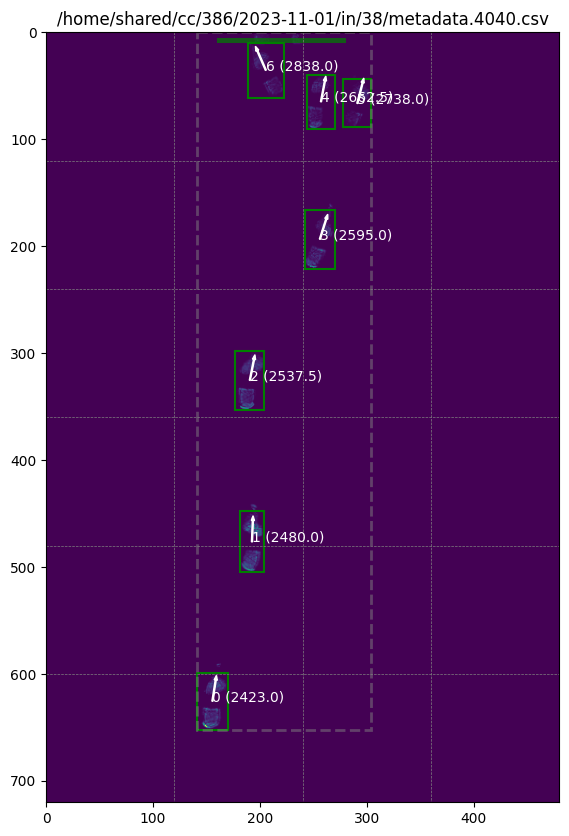

In [29]:
# This line is a workaround to display the figure as a static image in this notebook when generated programatically by papermill
# It isn't necessary when working interactively with ipywidgets (the plot will be rended in the preceding cell)
path_fig

In [30]:
path_fig.savefig(fname = trial_folder / 'path.png')

# Save Footsteps in `steps.raw.npz`

In [31]:
trial = np.load(trial_folder / 'trial.npz')['arr_0']

In [32]:
footsteps = {}

for i, row in metadata.iterrows():
  footsteps[i] = trial[row.StartFrame:row.EndFrame, row.YMin:row.YMax, row.XMin:row.XMax]

In [33]:
raw_footsteps = {}

for i, r in metadata.query('path_order > 0').iterrows():
  raw_footsteps[str(i)] = trial[r.StartFrame:r.EndFrame, r.YMin:r.YMax, r.XMin:r.XMax]

np.savez_compressed(trial_folder / 'steps.raw.npz', **raw_footsteps)

# Remove all other pressure data

In [34]:
zeroed_trial = np.zeros_like(trial)

for (i, r), f in zip(metadata.query('path_order > 0').iterrows(), raw_footsteps):
  zeroed_trial[r.StartFrame:r.EndFrame, r.YMin:r.YMax, r.XMin:r.XMax] = f

np.savez_compressed(trial_folder / 'trial.zeroed.npz', zeroed_trial)

# Align Footsteps

In [35]:
import preprocess_footsteps

In [36]:
preprocessed_footsteps, preprocessed_metadata = preprocess_footsteps.preprocess_footsteps(footsteps, metadata, h=100, w=100)

In [37]:
preprocessed_metadata

,Unnamed: 0,FootstepID,StartFrame,EndFrame,YMin,YMax,XMin,XMax,Timestamp,Gate,...,Date,Direction,SwipeN,path_order,heading_angle,is_anchor,is_on_path,RotationAngle,Orientation,Side
0,0,0,2389,2457,599,652,141,170,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,1.414661,False,False,8.945904,False,True
1,1,1,2445,2515,448,505,181,204,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,1.529053,False,False,2.391743,False,False
2,2,2,2502,2573,298,353,177,204,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,1.374457,False,False,11.249392,False,True
3,3,3,2557,2633,166,221,242,270,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,1.265754,False,False,17.447147,False,False
4,4,4,2617,2708,40,90,244,270,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,1.383193,False,False,10.748892,False,True
5,5,5,2681,2795,44,89,278,304,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,1.318893,False,False,15.196793,False,False
6,6,6,2759,2917,10,61,189,222,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,1.982706,False,False,-26.544724,False,True
7,7,7,2865,3149,0,12,229,241,2023-10-31 09:28:31,1,...,2023-11-01,in,38,0,2.111629,True,True,-30.987414,True,False
8,8,8,2947,3101,0,14,193,210,2023-10-31 09:28:31,1,...,2023-11-01,in,38,-1,2.972960,False,False,-75.415375,True,True


In [38]:
def get_human_readable_side_label(boolean_side_value):
  return 'Left' if boolean_side_value else 'Right'

preprocessed_metadata['SideLabel'] = preprocessed_metadata.Side.apply(get_human_readable_side_label) 

In [39]:
preprocessed_footsteps.shape

(9, 101, 100, 100)

In [40]:
preprocessed_p100s = preprocessed_footsteps.max(axis=1)

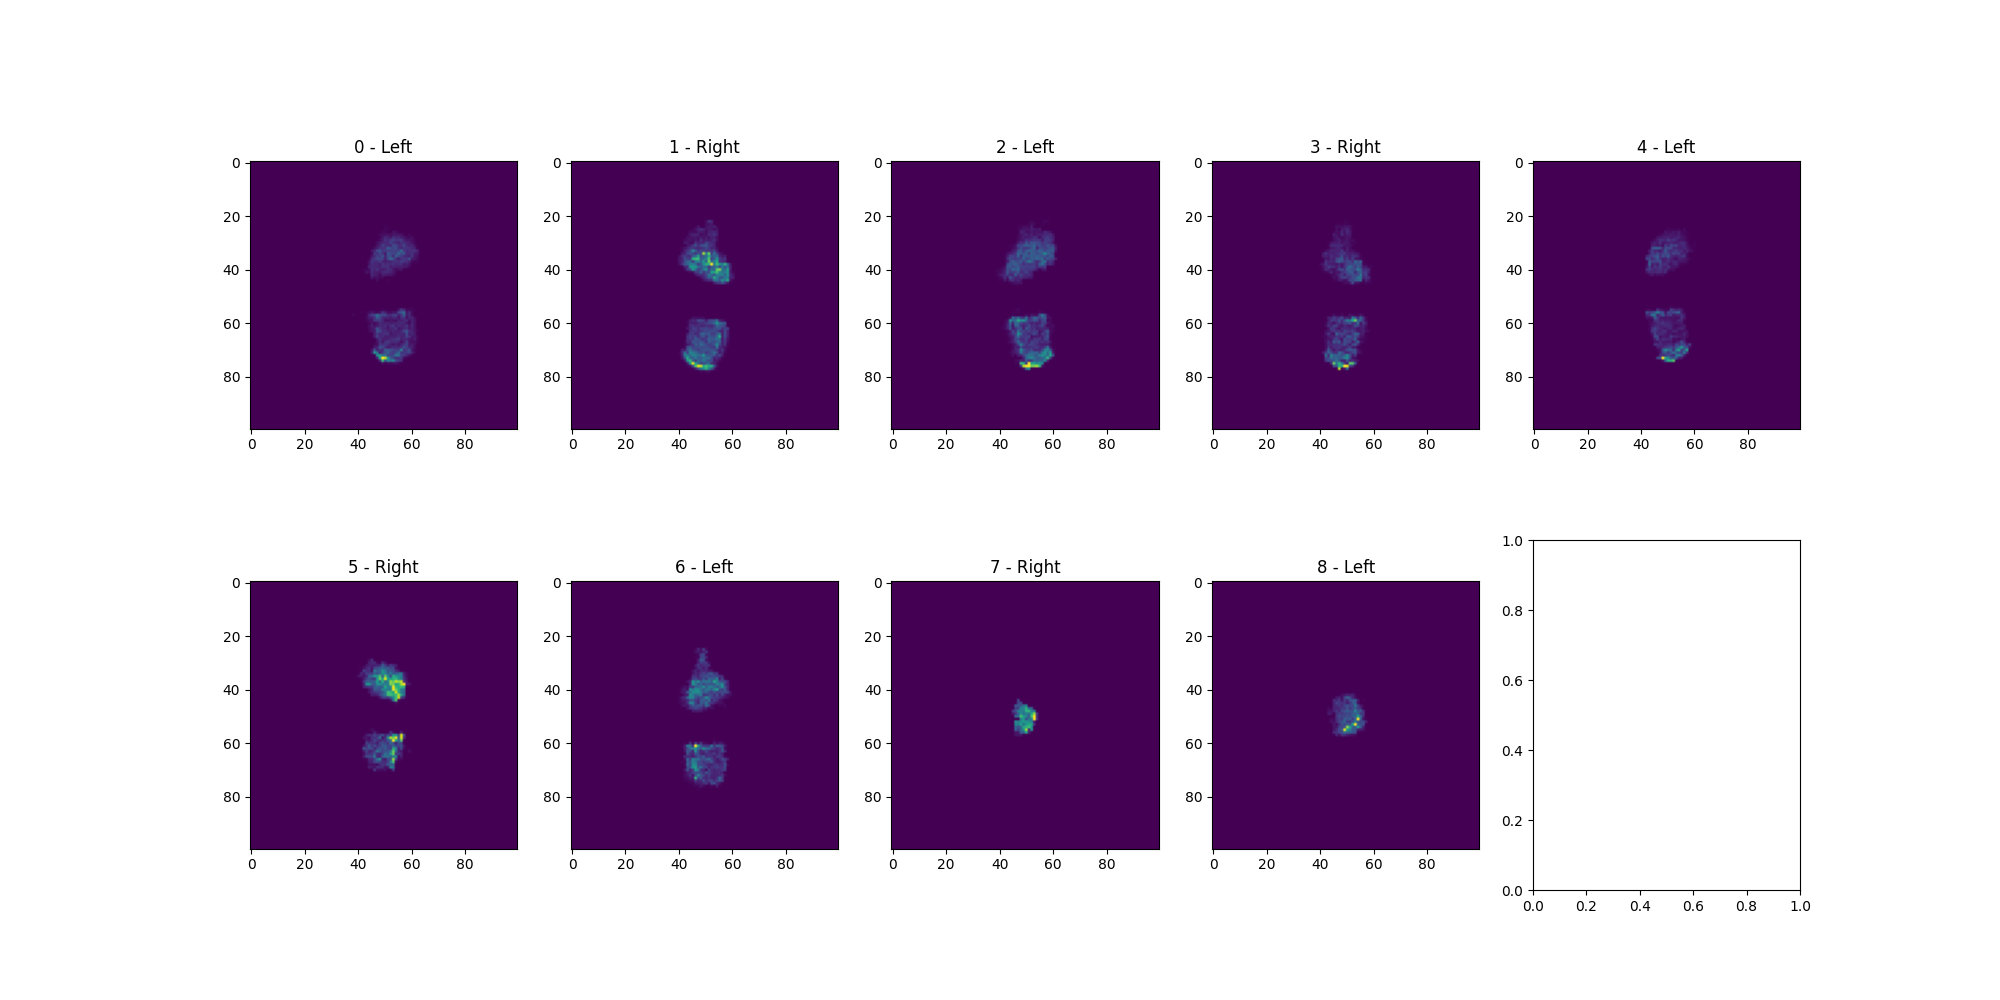

In [41]:
ncols = 5
nrows = (len(metadata) // ncols) + 1
aligned_fig, aligned_axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5*nrows), squeeze=False)

for i, f in enumerate(preprocessed_p100s):
  r = i // ncols
  c = i % ncols

  ax = aligned_axes[r][c]

  m = preprocessed_metadata.iloc[i]

  ax.set_title(f'{m.FootstepID} - {m.SideLabel}')

  ax.imshow(f)

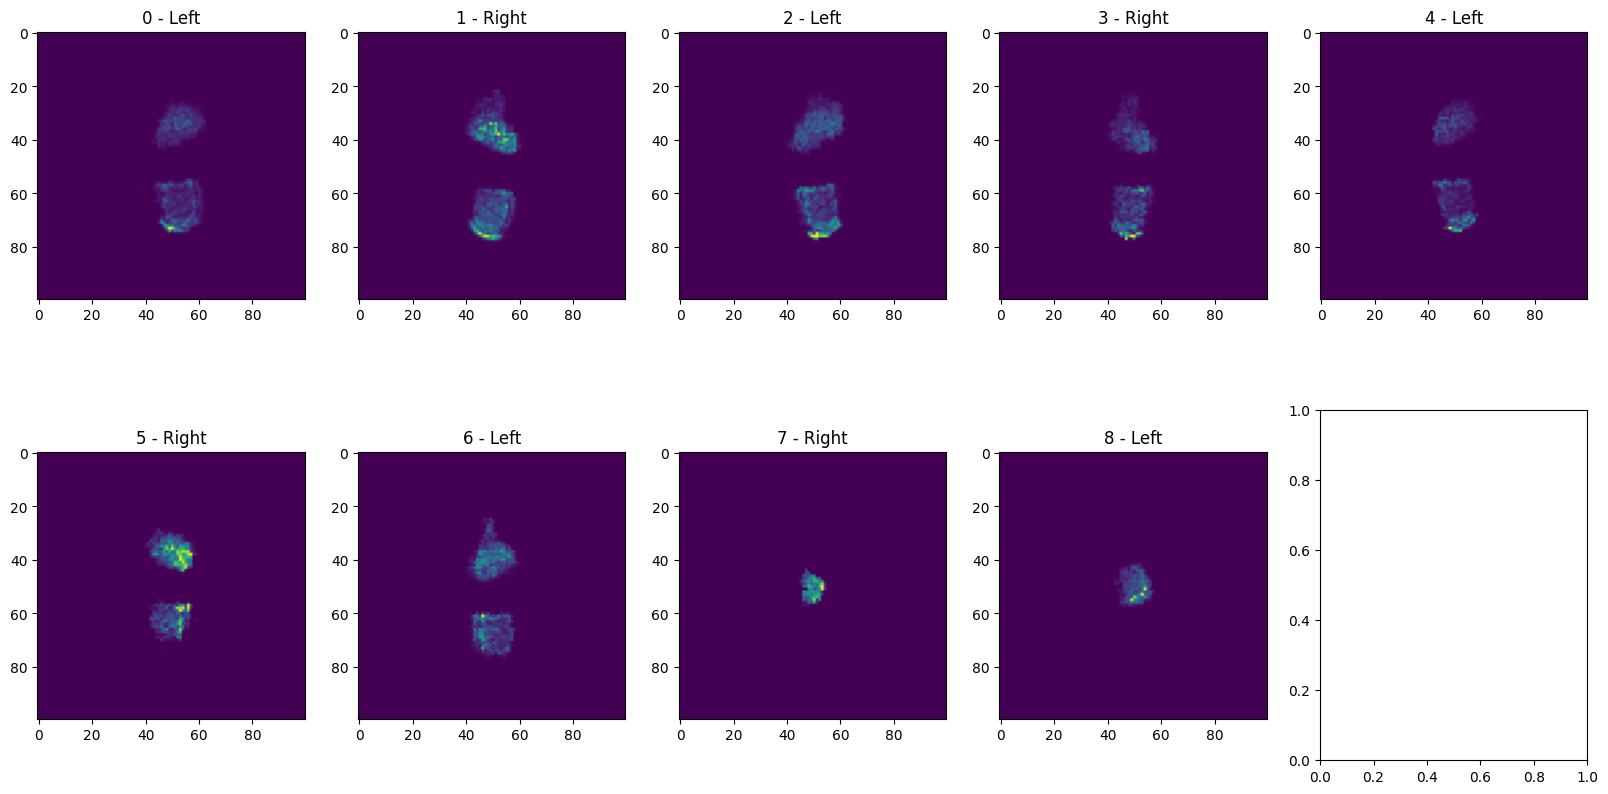

In [42]:
aligned_fig

In [43]:
preprocessed_footsteps_dict = {str(i): f for i, f in enumerate(preprocessed_footsteps)}
np.savez_compressed(trial_folder / 'steps.npz', **preprocessed_footsteps_dict)

# Invert Left Footsteps for Uniformity

In [44]:
# left_idx = preprocessed_metadata.query('SideLabel == "Left"').index

# preprocessed_footsteps[left_idx] = np.flip(preprocessed_footsteps[left_idx], axis=-1)

In [45]:
# preprocessed_p100s = preprocessed_footsteps.max(axis=1)

In [46]:
# ncols = 5
# nrows = (len(metadata) // ncols) + 1
# aligned_fig, aligned_axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5*nrows))

# for i, f in enumerate(preprocessed_p100s):
#   r = i // ncols
#   c = i % ncols

#   ax = aligned_axes[r][c]

#   m = preprocessed_metadata.iloc[i]

#   ax.set_title(f'{m.FootstepID} - {m.SideLabel}')

#   ax.imshow(f)

# Register All Footsteps to the Anchor 

In [47]:
# import dipy
# from dipy.align.imwarp import SymmetricDiffeomorphicRegistration
# from dipy.align.metrics import SSDMetric

# def nonlinear_registration(img1,img2,th = None, interpolation = 'linear'):
#     """Apply deformable transformation to register img2 to img1. Uses sum of
#     squared differences metric to create optimal deformation field. Default
#     interpolation = 'linear' to use linear interpolation, otherwise 'nearest'
#     to use nearest neighbor.

#     Returns deformation field F and warped image img2_x.
#     """
#     # transform img1 and img2 into binary images if necessary
#     if th is None:
#         img1_bin = np.float32(img1 > img1.max()/100)
#         img2_bin = np.float32(img2 > img2.max()/100)
#     else:
#         img1_bin = np.float32(img1 > th)
#         img2_bin = np.float32(img2 > th)

#     # use sum of squared differences  (can modify this)
#     metric = SSDMetric(dim = 2)

#     # create diffeomorphic registration object
#     sdr = SymmetricDiffeomorphicRegistration(metric,level_iters = [40,20,10])

#     # optimize
#     reg = sdr.optimize(img1_bin, img2_bin)

#     # apply transformation
#     img2_x = reg.transform(img2, interpolation = interpolation)

#     # save transformation matrix
#     F = reg.get_forward_field()

#     return F, img2_x

In [48]:
# registration_transforms = []
# registered_p100s = []
# anchor_p100 = preprocessed_p100s[anchor_id]


# for p100 in preprocessed_p100s:
#   transformation_matrix, registered_p100 = nonlinear_registration(anchor_p100, p100, th=10)
  
#   registration_transforms += [transformation_matrix]
#   registered_p100s += [registered_p100]

# registration_transforms = np.stack(registration_transforms, axis=0)
# registered_p100s = np.stack(registered_p100s, axis=0)

In [49]:
# # i.e., how much "movement" was needed to 
# registration_costs = np.abs(registration_transforms).sum(axis=(1,2,3))

# preprocessed_metadata['RegistrationCost'] = registration_costs

In [50]:
# ncols = 5
# nrows = (len(metadata) // ncols) + 1
# registered_fig, registered_axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5*nrows))

# for i, f in enumerate(registered_p100s):
#   r = i // ncols
#   c = i % ncols

#   ax = registered_axes[r][c]

#   m = preprocessed_metadata.iloc[i]

#   ax.set_title(f'{m.FootstepID} - {m.SideLabel} - {m.RegistrationCost:.2f}')

#   ax.imshow(f)

# Project into Pretrained UMAP Space - Do footsteps on the path cluster?

In [51]:
# import joblib
# import umap

In [52]:
# mapper = joblib.load('./p100_umap_model.pkl')

In [53]:
# flat_registered_p100s = np.stack(registered_p100s, axis=0).reshape((-1, 3000))
# flat_registered_p100s.shape

In [54]:
# embedding = mapper.transform(flat_registered_p100s)

In [55]:
# umap_fig, umap_ax = plt.subplots(figsize=(10,10))

# color_mapping = umap_ax.scatter(embedding[:, 0], embedding[:, 1], c=metadata.is_on_path)
# for i, e in enumerate(embedding):
#   umap_ax.annotate(i, (e[0], e[1]))

# umap_fig.colorbar(color_mapping)
